# Chapter 37. What is Machine Learning?

In short, machine learning is a collection of techniques used to _build models of data_.

Here, "learning" refers to the process of adjusting parameters based on observations made from an input data.

## Example: credit approval

Suppose that a bank receives several credit card applications every day.
The bank does not have a magical formula to evaluate these applications for approval.
However, the bank does have lots of data from previous customers. The bank could use this historical data to make _predictions_ about future applications.

Customer records are collected, such as salary, years in residence, outstanding loans, etc. The bank also keeps track of whether approving credit for that customer was a "good idea".

This data may drive the construction of a formula for credit approval that can be used on future applicants.
Note that this can also lead to societal implications, biases and discrimination against certain customer profiles if this appears in the data.

## Learning versus Design

Some problems do not require learning, and may instead rely on designing techniques from specifications.

Consider the problem of recognizing coins of different denominations, such as in vending machines. We want the machine to recognize quarters, dimes, nickels and pennies. We will contrast a "design" approach and a learning approach to tackle the same problem.

In the __learning approach__, we are given a sample of coins from each of the four denominations. We measure the size and mass of each coin and treat them as the input vector, and the coin denomination (quarter, dime, etc.) as the output. The learning algorithm searches for a function (hypothesis) that classifies the data set well.

In the __design approach__, we call the United States Mint and ask them about the specifications of different coins. We also ask them about the number of coins of each denomination in circulation to get the relative frequency of them. We then make a physical model of variations in size and mass due to wear and tear. Then, we compute the joint probability distribution of size, mass and coin denomination.

Both approaches are viable in some applications. The learning approach is possible when the function is unknown. The design approach is suitable when there is not enough training data or when the pattern can be anticipated.

## When to learn from data?

Typically, the following are indicators that a learning approach is suitable:

- You suspect there is a pattern in the data.
- You do not know such pattern.
- You have data.

## Exercise

Answer if a learning or design approach is more suitable for each of the following problems.

- a) Determining the age at which a particular medical test should be performed.
- b) Classifying numbers into primes and non-primes.
- c) Detecting potential fraud in credit card charges.
- d) Determining the time it would take a falling object to hit the ground.
- e) Determining the optimal cycle for traffic lights in a busy intersection.

## Categories of Machine Learning

The two main types of machine learning are desrcribed below. They rely on combination of _features_ (input variables) and _labels_ (prediction).

__Supervised learning__: models the relationship between measured features (input) of data and some labels associated with the data. Once this model is determined, it can be used to apply labels to new data. This type of learning can be further subdivided into _classification_ and _regression_.

__Unsupervised learning__: models features of a dataset without reference to any label. Includes tasks such as _clustering_ and _dimensionality reduction_.


Other approaches to the task of learning exist and may utilize a mix of both supervised and unsupervised (e.g.: semi-supervised, self-supervised).

## Classification: Predicting Discrete Labels

Suppose we have a dataset with two features (types of variables) and two _class labels_ "blue" or "red".

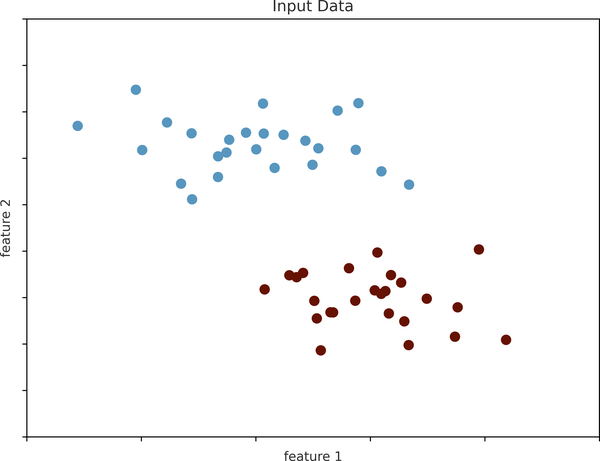


We will start with a simple assumption. Assume the data can be separated by drawing a staight line through the plane between them.

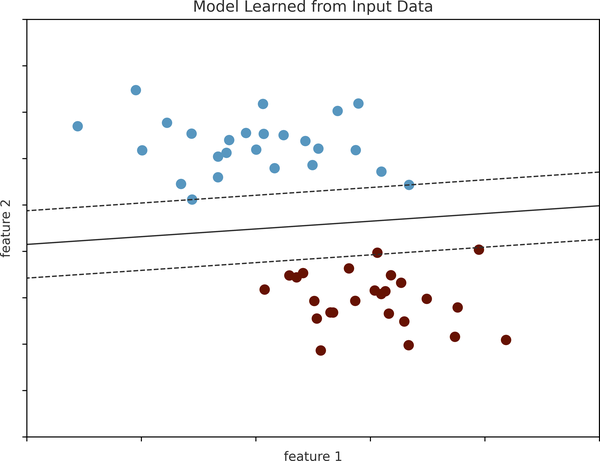

The _model_ parameters is what defines such straight line. The optimal values for these parameters are _learned from the data_ in a procedure called _training_.

Once the model has been trained, it can be applied to unlabeled data.

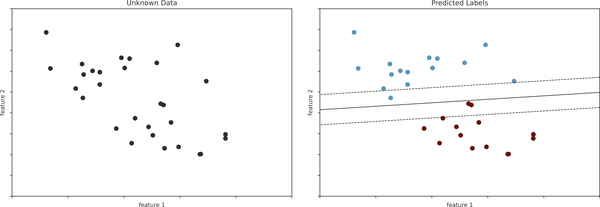

## Regression: Predicting Continuous Labels

In regression, the prediction is a continuous value rather than a class label (e.g.: linear regression). There are many possible regression models.

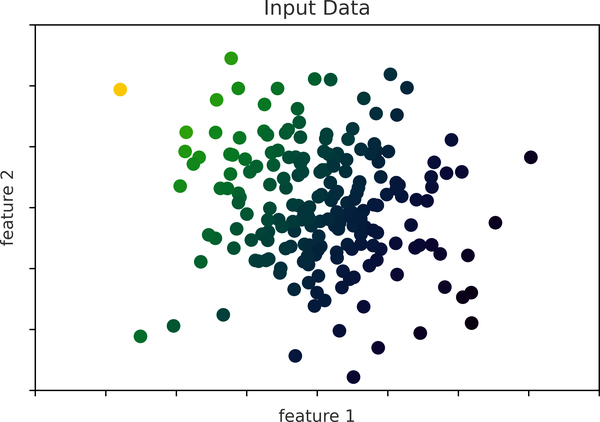

The same plot in 3D:

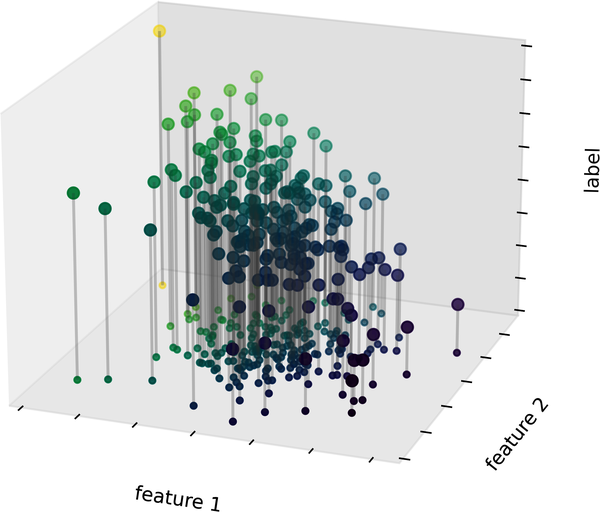

## Clustering: Inferring Labels on Unlabeled Data

Clustering does not use any labels. That is, it is a form of "unsupervised learning". It identifies patterns in the feature distributions to cluster (group) points into discrete categories.

Can you spot patterns in the example below?

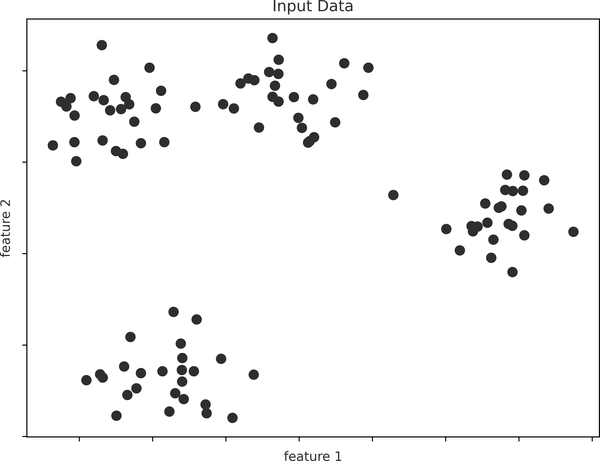

A clustering algorithm may produce the following:

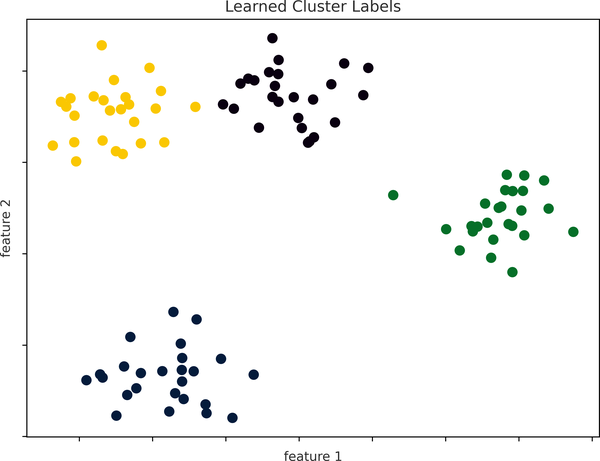

# Chapter 38. Introducing Scikit-Learn

Scikit-learn is a library that provides efficient implementations of machine learning algorithms.

## Data representation in Scikit-Learn


### The features matrix
Scikit-learn requires data to be in a _table_ format, typically as a two-dimensional numerical array. We will call this table the _features matrix_. A feature matrix `X` is assumed to be two-dimensional, with shape `(n_samples, n_features)`, generally stored in a NumPy array or Pandas DataFrame.

Samples are individual observations, features are each variable of that observation.


### The target array

In supervised learning, we need an array of labels, hereon called the _label_ or _target array_ `y`. This target array is usually one-dimensional with length `n_samples` generally stored in a NumPy array or Pandas Series.

The _target array_ is the characteristic we want to _predict_ from the features. It is the _dependable_ variable.

Example using the _iris_ dataset.

In [ ]:
%matplotlib inline
import seaborn as sns
iris = sns.load_dataset('iris')
sns.pairplot(iris, hue='species', height=1.5);

We will construct the feature matrix `X` by dropping the `'species'` column, and make the `'species'` column the target array `y`.

In [ ]:
X_iris = iris.drop('species', axis=1)
y_iris = iris['species']

print(X_iris.shape)
print(y_iris.shape)

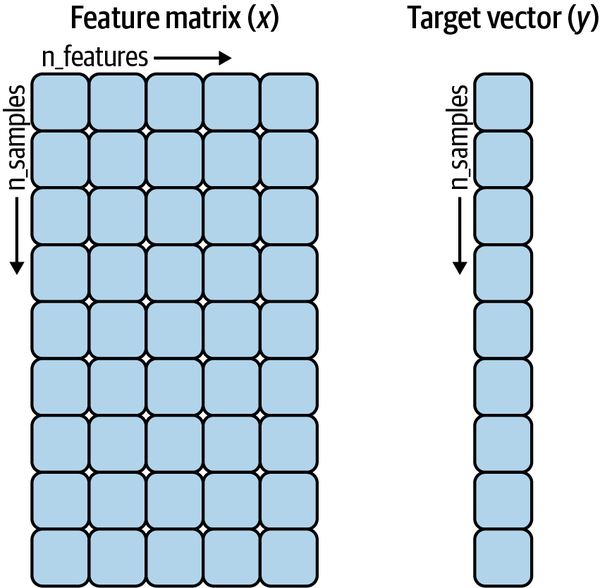

## The Estimator API

Scikit-Learn was designed with the following principles in mind:

- __Consistency__: All objects share a common interface.
- __Inspection__: All specified parameter values are exposed.
- __Limited object hierarchy__: Built on top of existing formats (NumPy arrays, Pandas DataFrames, etc).
- __Composition__: Allows combining fundamental algorithms into sophisticated pipelines.


The typical sequence of steps taken while using Scikit-Learn's Estimator API:

1. Choose a class of model and import it.
2. Choose the model hyperparameters.
3. Arrange the data into a features matrix and target vector.
4. Fit the model to your data by calling the `fit` method.
5. Apply the model to new data:
    - For supervised, we use the `predict` method.
    - For unsupervised, we use the `transform` or `predict` method.

## Supervised Learning Example: A Simple Linear Regression

We will generate a random set of points to "learn" their underlying function.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


rng = np.random.RandomState(0)
x = 10*rng.rand(50)
y = 2*x-1+rng.randn(50)
plt.scatter(x, y);

Notice the trend in the data. Our goal is to "learn" a function that can predict the y value given an x value.

### 1. Choosing the model

Scikit-Learn represents every class of model by a Python class. For this example, we will use the `LinearRegression` model.

In [ ]:
from sklearn.linear_model import LinearRegression

### 2. Choose the model hyperparameters

In this step, we instantiate the model into an object. We will set the parameter `fit_intercept=True`.

In [ ]:
model = LinearRegression(fit_intercept=True)
model

This only instantiates the model. We now need to __apply it to the data__.

### 3. Arrange the data into features matrix and target vector

Recall that the features matrix must be `(n_samples, n_features)`. Our `x` array has shape `(50)`. So, we must give it a new dimension and make it `(50, 1)`.

Note that `y` is already in the approriate format for the target vector.

In [ ]:
X = x[:, np.newaxis]
X.shape

### 4. Fit the model to the data

Now we apply the model to the data using the `fit` method.

In [ ]:
model.fit(X,y)

Let us inspect the _learned_ parameters of the model. They are the _coefficient_ `model.coef_` and the intercept `model.intercept_`. In Scikit-Learn, by convention, all learned parameters have _trailing underscores_.

In [ ]:
print(model.coef_)
print(model.intercept_)

### 5. Predict labels for unknown data

In [ ]:
xfit = np.linspace(-1, 11)

Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

plt.scatter(x, y)
plt.plot(xfit, yfit, color='r');

## Supervised Learning Example: Iris classification

We will now use a real dataset to train our model. Since we would like to evaluate the model on data that we have not seen before, we will split it into a _traning set_ and a _testing set_. We will use a model named `Gaussian naive Bayes`.

__Training set__: Used in the "learning" phase. This part of the data is used to adjust the model's parameters.

__Test set__: Used in the evaluation phase. It _should never_ be used in training, otherwise the model's ability to generalize may be compromised.

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                random_state=1)

In [ ]:
from sklearn.naive_bayes import GaussianNB # 1. choose model class
model = GaussianNB()                       # 2. instantiate model
model.fit(Xtrain, ytrain)                  # 3. fit model to data
y_model = model.predict(Xtest)   

In [ ]:
# Measure the accuracy of the model

from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

This classifier can predict 97% of test cases correctly!

## Unsupervised Learning Example: Dimensionality Reduction

We would like to visualize the Iris data. However, recall that the `iris` dataset is four-dimensional: there are four features recorded for each sample.

Visualizing four-dimension is a non-trivial task. To enable visualization we will resort to the process defined as _dimensionality reduction_.

We will use _principal component analysis_ (PCA), which is a fast linear dimensionality reduction technique.

In [ ]:
from sklearn.decomposition import PCA
model = PCA(n_components=2)  # We want to reduce the data to 2 components (two-dimensional)
model.fit(X_iris)
X_2D = model.transform(X_iris)  # transform the data

In [ ]:
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]
sns.lmplot(data=iris, x='PCA1', y='PCA2', hue='species', fit_reg=False);